# Task 1

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <style>
        body {
            font-family: Arial, sans-serif;
            line-height: 1.6;
            background-color: #f9f9f9;
            color: #333;
            padding: 20px;
        }
        h1, h2, h3 {
            color: #2c3e50;
        }
        .important {
            background-color: #fffae6;
            border-left: 6px solid #f1c40f;
            padding: 10px;
            margin-bottom: 20px;
        }
        .submission {
            background-color: #e8f4fd;
            border-left: 6px solid #2196f3;
            padding: 10px;
            margin-bottom: 20px;
        }
        ul {
            margin-left: 20px;
        }
        .tips {
            background-color: #e8f5e9;
            border-left: 6px solid #4caf50;
            padding: 10px;
            margin-top: 20px;
        }
    </style>
</head>
<body>

<h1>NER Fine-Tuning Task</h1>

<div class="important">
    <h2>Important Setup:</h2>
    <ul>
        <li>Make sure to use <strong>GPU acceleration</strong> if available in your environment for faster training</li>
        <li>You can use <strong>Kaggle</strong> which offers free GPU access for this task</li>
        <li>Save your work frequently and ensure all files are saved properly</li>
    </ul>
</div>

<div class="submission">
    <h2>Submission Requirements:</h2>
    <ul>
        <li>Send your completed work as files (Jupyter Notebook, Python files, and any additional files)</li>
        <li><strong>Include:</strong> Your notebook, any custom datasets, model files, and documentation</li>
        <li>Ensure all code is runnable and well-documented</li>
    </ul>
</div>

<h2>Your Tasks:</h2>
<p><strong>Fine-tune a pretrained model on a Named Entity Recognition (NER) task.</strong></p>

<h3>Keep in mind:</h3>
<ul>
    <li><strong>Loss function</strong></li>
    <li><strong>Optimizer</strong></li>
    <li><strong>Weight initialization</strong> (if applicable)</li>
    <li><strong>Splitting data</strong> into train, validation, and test sets</li>
    <li><strong>Evaluation metrics:</strong> e.g., F1-score, precision, recall</li>
</ul>

<h3>Allowed Resources:</h3>
<p>You are allowed to use:</p>
<ul>
    <li>AI tools</li>
    <li>YouTube tutorials</li>
    <li>Online documentation, blogs, and forums</li>
</ul>
<p><em>In short: Feel free to use the internet for research and implementation.</em></p>

<h3>Dataset Requirements:</h3>
<ul>
    <li><strong>You need to collect or use an Azerbaijani dataset.</strong></li>
</ul>

<h3>Before Starting, Research These Topics:</h3>
<ul>
    <li><strong>Tokenization</strong></li>
    <li><strong>NER labeling schemes</strong> (such as <strong>BIO encoding</strong>)</li>
    <li><strong>Pretrained transformer models for NER:</strong> e.g., BERT, RoBERTa, etc.</li>
</ul>

<h3>Libraries and Frameworks:</h3>
<ul>
    <li>You are allowed to use existing libraries and frameworks:</li>
    <li>Examples: <strong>Hugging Face Transformers, spaCy</strong>, etc.</li>
</ul>

<div class="tips">
    <h3>Recommended:</h3>
    <ul>
        <li>Document your experiment steps, including <strong>hyperparameter choices</strong>, <strong>training logs</strong>, and <strong>evaluation results</strong>.</li>
        <li>If possible, <strong>visualize your results</strong> (e.g., using matplotlib or seaborn for learning curves, confusion matrices, etc.).</li>
    </ul>
</div>

</body>
</html>

In [ ]:
# For example, here is one library that can be used to complete this task (finding a different one, or building fine-tuning from scratch in pytorch is also an option)
# https://flairnlp.github.io/docs/category/tutorial-2-training-models

The code was run in Google Colab environment.

## Code

### Install required dependencies


After running 2 cells below, you may need to restart the session, if the code is being run in Colab.

In [ ]:
# for Jupyter:
!pip install -U datasets
!pip install transformers tokenizers seqeval -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.7.0
    Uninstalling fsspec-2025.7.0:
      Successfully uninstalled fsspec-2025.7.0
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.7.0 requires fsspec==2025.7.0, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pla

^C


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


### Required imports

In [ ]:
import datasets
import numpy as np
from transformers import DataCollatorForTokenClassification
from transformers import BertTokenizerFast
from transformers import AutoModelForTokenClassification

### Loading data

In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset

ds = load_dataset("LocalDoc/azerbaijani-ner-dataset")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/13.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99545 [00:00<?, ? examples/s]

In [ ]:
ds.shape

{'train': (99545, 3)}

Our data does not have val/test split in the beginning. We need to split it before we apply transformations as needed.

### train/val/test split

In [ ]:
from datasets import DatasetDict

# First split train into train + temp (80% train, 20% temp)
train_testvalid = ds['train'].train_test_split(test_size=0.2, seed=42)

# Then split temp into validation and test (50% each of the 20%)
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)

# Combine into final DatasetDict
ds = DatasetDict({
    'train': train_testvalid['train'],
    'validation': test_valid['train'],  # Note: 'train' here refers to the first split of test_valid
    'test': test_valid['test']
})

print(ds)

DatasetDict({
    train: Dataset({
        features: ['index', 'tokens', 'ner_tags'],
        num_rows: 79636
    })
    validation: Dataset({
        features: ['index', 'tokens', 'ner_tags'],
        num_rows: 9954
    })
    test: Dataset({
        features: ['index', 'tokens', 'ner_tags'],
        num_rows: 9955
    })
})


In [ ]:
ds['train']

Dataset({
    features: ['index', 'tokens', 'ner_tags'],
    num_rows: 79636
})

In [ ]:
print(ds['train'].features)
# Should show something like: {'ner_tags': Value('string')}

{'index': Value('string'), 'tokens': Value('string'), 'ner_tags': Value('string')}


All features are datatype of Value('string').
\
NER tags and tokens need to be changed to be processed as Sequences of Lists.
\
index is not needed in this case, as they do not hold any useful information

In [ ]:
ds['train']['ner_tags']

Column(['[3, 0, 0, 0, 1, 1, 0, 0, 0, 14, 0, 0, 0, 0, 0, 0]', '[0, 14, 3, 3, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]', '[0, 0, 0, 0, 0, 0, 17, 6, 0, 0, 0, 17, 4, 9, 0, 0, 0, 0, 0]', '[0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]', '[0, 0, 0, 0, 16, 0, 0, 0, 0, 17, 0, 0, 0, 0, 15, 0]'])

NER tags are stored as strings, in following parts, it's been taken care of.

### preprocessing data

In [ ]:
ds = ds.select_columns(['tokens', 'ner_tags'])

ds

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 79624
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 9950
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 9954
    })
})

In following cells of code, I tried to make dictionaries in forms of {NER tag: Description} and {index: NER tag}, and vice-versa.

In [ ]:
# Own description in HuggingFace

chars = '''
0: O: Outside any named entity
1: PERSON: Names of individuals
2: LOCATION: Geographical locations, both man-made and natural
3: ORGANISATION: Names of companies, institutions
4: DATE: Dates or periods
5: TIME: Times of the day
6: MONEY: Monetary values
7: PERCENTAGE: Percentage values
8: FACILITY: Buildings, airports, etc.
9: PRODUCT: Products and goods
10: EVENT: Events and occurrences
11: ART: Artworks, titles of books, songs
12: LAW: Legal documents
13: LANGUAGE: Languages
14: GPE: Countries, cities, states
15: NORP: Nationalities or religious or political groups
16: ORDINAL: Ordinal numbers
17: CARDINAL: Cardinal numbers
18: DISEASE: Diseases and medical conditions
19: CONTACT: Contact information, e.g., phone numbers, emails
20: ADAGE: Proverbs, sayings
21: QUANTITY: Measurements and quantities
22: MISCELLANEOUS: Miscellaneous entities
23: POSITION: Professional or social positions
24: PROJECT: Names of projects or programs
'''

In [ ]:
arbitrary_list = []
for i, char in enumerate(chars.split('\n')):
  arbitrary_list.append(char.split(':'))

arbitrary_list[1:-1]

[['0', ' O', ' Outside any named entity'],
 ['1', ' PERSON', ' Names of individuals'],
 ['2', ' LOCATION', ' Geographical locations, both man-made and natural'],
 ['3', ' ORGANISATION', ' Names of companies, institutions'],
 ['4', ' DATE', ' Dates or periods'],
 ['5', ' TIME', ' Times of the day'],
 ['6', ' MONEY', ' Monetary values'],
 ['7', ' PERCENTAGE', ' Percentage values'],
 ['8', ' FACILITY', ' Buildings, airports, etc.'],
 ['9', ' PRODUCT', ' Products and goods'],
 ['10', ' EVENT', ' Events and occurrences'],
 ['11', ' ART', ' Artworks, titles of books, songs'],
 ['12', ' LAW', ' Legal documents'],
 ['13', ' LANGUAGE', ' Languages'],
 ['14', ' GPE', ' Countries, cities, states'],
 ['15', ' NORP', ' Nationalities or religious or political groups'],
 ['16', ' ORDINAL', ' Ordinal numbers'],
 ['17', ' CARDINAL', ' Cardinal numbers'],
 ['18', ' DISEASE', ' Diseases and medical conditions'],
 ['19', ' CONTACT', ' Contact information, e.g., phone numbers, emails'],
 ['20', ' ADAGE', '

In [ ]:
ner_tags_id_to_char = {}
ner_tags_char_description = {}
for lst in arbitrary_list[1:-1]:
  ner_tags_id_to_char[lst[0]] = lst[1].strip()
  ner_tags_char_description[lst[1].strip()] = lst[2].strip()

In [ ]:
ner_tags_char_description, ner_tags_id_to_char

({'O': 'Outside any named entity',
  'PERSON': 'Names of individuals',
  'LOCATION': 'Geographical locations, both man-made and natural',
  'ORGANISATION': 'Names of companies, institutions',
  'DATE': 'Dates or periods',
  'TIME': 'Times of the day',
  'MONEY': 'Monetary values',
  'PERCENTAGE': 'Percentage values',
  'FACILITY': 'Buildings, airports, etc.',
  'PRODUCT': 'Products and goods',
  'EVENT': 'Events and occurrences',
  'ART': 'Artworks, titles of books, songs',
  'LAW': 'Legal documents',
  'LANGUAGE': 'Languages',
  'GPE': 'Countries, cities, states',
  'NORP': 'Nationalities or religious or political groups',
  'ORDINAL': 'Ordinal numbers',
  'CARDINAL': 'Cardinal numbers',
  'DISEASE': 'Diseases and medical conditions',
  'CONTACT': 'Contact information, e.g., phone numbers, emails',
  'ADAGE': 'Proverbs, sayings',
  'QUANTITY': 'Measurements and quantities',
  'MISCELLANEOUS': 'Miscellaneous entities',
  'POSITION': 'Professional or social positions',
  'PROJECT': 'Nam

In [ ]:
type(ds['train']['ner_tags'][3])

str

In [ ]:
# Some rows in dataset were type None.
# This datapoints will be a headache, so let's look at how many are there, and get rid of them.

none_indices = [i for i, x in enumerate(ds['train']['ner_tags']) if x is None]
print(f"Found {len(none_indices)} rows with 'ner_tags' = None")

Found 0 rows with 'ner_tags' = None


In [ ]:
# Filter out rows where 'ner_tags' is None
ds['train'] = ds['train'].filter(lambda example: example['ner_tags'] is not None)

Filter:   0%|          | 0/79624 [00:00<?, ? examples/s]

In [ ]:
none_indices = [i for i, x in enumerate(ds['train']['ner_tags']) if x is None]
print(f"Found {len(none_indices)} rows with 'ner_tags' = None")

Found 0 rows with 'ner_tags' = None


Another important part is to clean the data.
\
In Named Entity Recognition, models expect to work with batches, like sequences of lists.
\
\
We have tokens (words) and NER tags. NER tags must be **integers**, because they represent the **id's**, and **tokens** should be properly split into words.
\
\
Currently, they look like the following:

In [ ]:
ds['train']['tokens']

Column([['Nazirliyin', 'mətbuat', 'xidmətinin', 'rəhbəri', 'Arsrun', 'Ovanesyan', 'bildirib', 'ki', ',', 'Azərbaycan', 'silahlı', 'qüvvələri', 'sərhəddi', 'gərginlikdə', 'saxlayır', '.'], ['“', 'Azərbaycan', 'Respublikası', 'İpoteka', 'və', 'Kredit', 'Zəmanət', 'Fondunun', 'vəsaiti', 'hesabına', 'ipoteka', 'kreditinin', ',', 'o', 'cümlədən', 'güzəştli', 'ipoteka', 'kreditinin', 'verilməsi', 'Qaydası', '”', 'nda', 'dəyişikliklər', 'edilib', '.'], ['Belə', 'ki', ',', 'müştərilər', 'hesaba', 'minimum', '20', 'AZN', 'ilkin', 'mədaxil', 'etməklə', '2', 'illik', 'Visa', 'kartlarını', 'əldə', 'edə', 'bilərlər', '.'], ['Şükürlər', 'olsun', 'ki', ',', 'dövlətimiz', 'və', 'xalqımız', 'şəhidlərimizin', 'xatirəsini', 'daima', 'uca', 'tutur', ',', 'onların', 'ruhlarını', 'böyük', 'ehtiramla', 'yad', 'edir', '.'], ['Üçüncü', 'ayə', 'isə', 'insanları', 'üç', 'qrupa', 'ayırır', ':', '"', '1', ')', 'İman', 'gətirənlər', '–', "mö'minlər", '.']])

In [ ]:
ds['train']['ner_tags']

Column([[3, 0, 0, 0, 1, 1, 0, 0, 0, 14, 0, 0, 0, 0, 0, 0], [0, 14, 3, 3, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 17, 6, 0, 0, 0, 17, 4, 9, 0, 0, 0, 0, 0], [0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 16, 0, 0, 0, 0, 17, 0, 0, 0, 0, 15, 0]])

In [ ]:
unique_elements = []
for i in arbitrary_list[1:-1]:
  unique_elements.append(i[1].strip())

unique_elements

['O',
 'PERSON',
 'LOCATION',
 'ORGANISATION',
 'DATE',
 'TIME',
 'MONEY',
 'PERCENTAGE',
 'FACILITY',
 'PRODUCT',
 'EVENT',
 'ART',
 'LAW',
 'LANGUAGE',
 'GPE',
 'NORP',
 'ORDINAL',
 'CARDINAL',
 'DISEASE',
 'CONTACT',
 'ADAGE',
 'QUANTITY',
 'MISCELLANEOUS',
 'POSITION',
 'PROJECT']

In [ ]:
import ast
import numpy as np
from datasets import Dataset, Features, Sequence, ClassLabel, Value

# proper conversion of 'token' features
def convert_string_to_list(example):
    example['tokens'] = ast.literal_eval(example['tokens'])
    return example

# proper conversion of 'ner_tags' features
# 1. First convert string lists to actual lists of integers
def convert_tags(example):
    tag_list = ast.literal_eval(example['ner_tags'])  # Convert string to list
    return {'ner_tags': [int(tag) for tag in tag_list]}  # Ensure all elements are integers

# 2. Define your NER tag classes (customize these to match your labels)
tag_names = unique_elements

# 3. Apply conversion and casting
ds = ds.map(convert_string_to_list)
ds = ds.map(convert_tags, batched=False)

ds = ds.cast_column('ner_tags', Sequence(feature=ClassLabel(names=tag_names)))
ds = ds.cast_column('tokens', Sequence(feature=Value(dtype='string')))

Map:   0%|          | 0/79624 [00:00<?, ? examples/s]

Map:   0%|          | 0/9950 [00:00<?, ? examples/s]

Map:   0%|          | 0/9954 [00:00<?, ? examples/s]

In [ ]:
# Below is the Correct datatype.

ds['train'].features

{'tokens': List(Value('string')),
 'ner_tags': List(ClassLabel(names=['O', 'PERSON', 'LOCATION', 'ORGANISATION', 'DATE', 'TIME', 'MONEY', 'PERCENTAGE', 'FACILITY', 'PRODUCT', 'EVENT', 'ART', 'LAW', 'LANGUAGE', 'GPE', 'NORP', 'ORDINAL', 'CARDINAL', 'DISEASE', 'CONTACT', 'ADAGE', 'QUANTITY', 'MISCELLANEOUS', 'POSITION', 'PROJECT']))}

In [ ]:
# Now, they look like this:

ds['train']['tokens']

Column([['Nazirliyin', 'mətbuat', 'xidmətinin', 'rəhbəri', 'Arsrun', 'Ovanesyan', 'bildirib', 'ki', ',', 'Azərbaycan', 'silahlı', 'qüvvələri', 'sərhəddi', 'gərginlikdə', 'saxlayır', '.'], ['“', 'Azərbaycan', 'Respublikası', 'İpoteka', 'və', 'Kredit', 'Zəmanət', 'Fondunun', 'vəsaiti', 'hesabına', 'ipoteka', 'kreditinin', ',', 'o', 'cümlədən', 'güzəştli', 'ipoteka', 'kreditinin', 'verilməsi', 'Qaydası', '”', 'nda', 'dəyişikliklər', 'edilib', '.'], ['Belə', 'ki', ',', 'müştərilər', 'hesaba', 'minimum', '20', 'AZN', 'ilkin', 'mədaxil', 'etməklə', '2', 'illik', 'Visa', 'kartlarını', 'əldə', 'edə', 'bilərlər', '.'], ['Şükürlər', 'olsun', 'ki', ',', 'dövlətimiz', 'və', 'xalqımız', 'şəhidlərimizin', 'xatirəsini', 'daima', 'uca', 'tutur', ',', 'onların', 'ruhlarını', 'böyük', 'ehtiramla', 'yad', 'edir', '.'], ['Üçüncü', 'ayə', 'isə', 'insanları', 'üç', 'qrupa', 'ayırır', ':', '"', '1', ')', 'İman', 'gətirənlər', '–', "mö'minlər", '.']])

In [ ]:
ds['train']['ner_tags']

Column([[3, 0, 0, 0, 1, 1, 0, 0, 0, 14, 0, 0, 0, 0, 0, 0], [0, 14, 3, 3, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 17, 6, 0, 0, 0, 17, 4, 9, 0, 0, 0, 0, 0], [0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 16, 0, 0, 0, 0, 17, 0, 0, 0, 0, 15, 0]])

Conversion was succesful!

### Count of NER tags

In [ ]:
ner_tag_count = {}

for example in ds['train']:
  for ner_tag in example['ner_tags']:
    ner_tag_count[ner_tag] = ner_tag_count.get(ner_tag, 0) + 1

In [ ]:
ner_tag_count

{3: 54178,
 0: 1121302,
 1: 47188,
 14: 30701,
 17: 19122,
 6: 3298,
 4: 22173,
 9: 6934,
 16: 5133,
 15: 4150,
 2: 11583,
 8: 6749,
 24: 2107,
 20: 232,
 11: 3908,
 22: 28816,
 21: 2709,
 23: 7118,
 10: 6727,
 18: 2394,
 13: 580,
 12: 507,
 5: 1864,
 19: 412,
 7: 1114}

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Keys will be more understandable, will be used in plotting

ner_tag_count_id_to_char = {ner_tags_id_to_char[str(i)]: j for i, j in zip(ner_tag_count, ner_tag_count.values())}
ner_tag_count_id_to_char

{'ORGANISATION': 54178,
 'O': 1121302,
 'PERSON': 47188,
 'GPE': 30701,
 'CARDINAL': 19122,
 'MONEY': 3298,
 'DATE': 22173,
 'PRODUCT': 6934,
 'ORDINAL': 5133,
 'NORP': 4150,
 'LOCATION': 11583,
 'FACILITY': 6749,
 'PROJECT': 2107,
 'ADAGE': 232,
 'ART': 3908,
 'MISCELLANEOUS': 28816,
 'QUANTITY': 2709,
 'POSITION': 7118,
 'EVENT': 6727,
 'DISEASE': 2394,
 'LANGUAGE': 580,
 'LAW': 507,
 'TIME': 1864,
 'CONTACT': 412,
 'PERCENTAGE': 1114}

In [ ]:
# Changing the key name from 'O' to 'Undefined'.

dict_copy = ner_tag_count_id_to_char.copy()
dict_copy['Undefined'] = dict_copy.pop('O')
dict_copy

{'ORGANISATION': 54178,
 'PERSON': 47188,
 'GPE': 30701,
 'CARDINAL': 19122,
 'MONEY': 3298,
 'DATE': 22173,
 'PRODUCT': 6934,
 'ORDINAL': 5133,
 'NORP': 4150,
 'LOCATION': 11583,
 'FACILITY': 6749,
 'PROJECT': 2107,
 'ADAGE': 232,
 'ART': 3908,
 'MISCELLANEOUS': 28816,
 'QUANTITY': 2709,
 'POSITION': 7118,
 'EVENT': 6727,
 'DISEASE': 2394,
 'LANGUAGE': 580,
 'LAW': 507,
 'TIME': 1864,
 'CONTACT': 412,
 'PERCENTAGE': 1114,
 'Undefined': 1121302}

In [ ]:
import pandas as pd

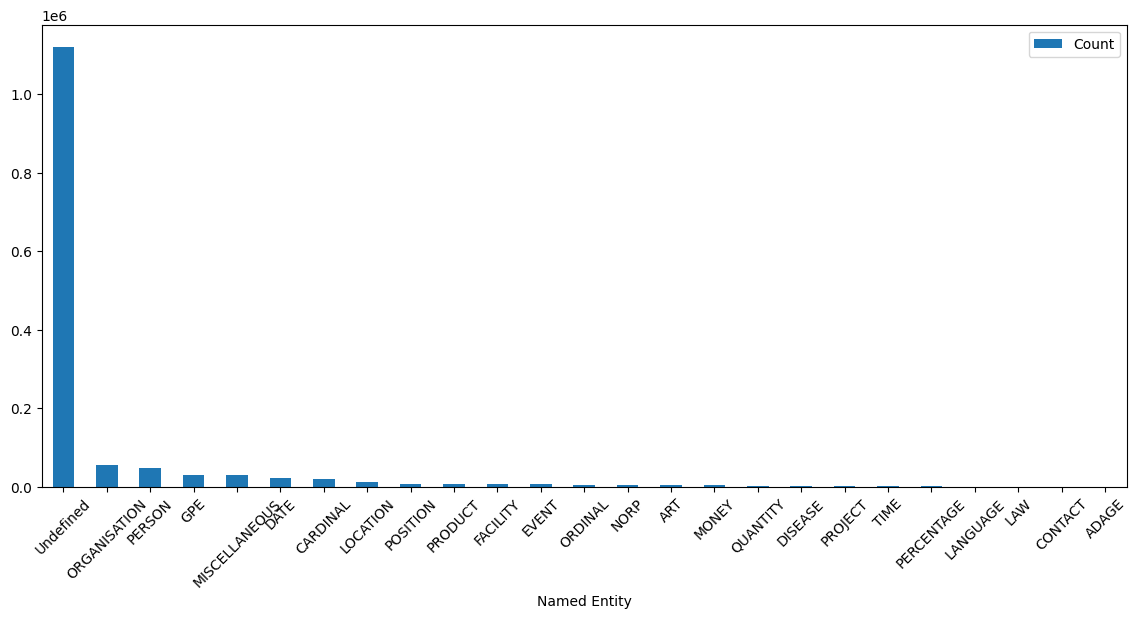

In [ ]:
# Plotting

d = {
    'Named Entity': dict_copy.keys(),
    'Count': dict_copy.values()
}

df = pd.DataFrame(d)
df.sort_values(by='Count', ascending=False).plot.bar(x='Named Entity', y='Count', figsize=(14, 6), rot=45)

plt.show()

Too much 'Undefined', which is id=0, meaning that we have "Outside any named entity" tags quite a lot.

In [ ]:
# tokenizer is bert-base-uncased, which will be fine-tuned.

tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
ds['train'][0]

{'tokens': ['Nazirliyin',
  'mətbuat',
  'xidmətinin',
  'rəhbəri',
  'Arsrun',
  'Ovanesyan',
  'bildirib',
  'ki',
  ',',
  'Azərbaycan',
  'silahlı',
  'qüvvələri',
  'sərhəddi',
  'gərginlikdə',
  'saxlayır',
  '.'],
 'ner_tags': [3, 0, 0, 0, 1, 1, 0, 0, 0, 14, 0, 0, 0, 0, 0, 0]}

In [ ]:
# id 101 and 102, are start of sequence and end of sequence tokens(Also seen as [CLS] and [SEP]).

example_text = ds['train'][0]
tokenized_input = tokenizer(example_text['tokens'], is_split_into_words=True)
tokens = tokenizer.convert_ids_to_tokens(tokenized_input['input_ids'])

word_ids = tokenized_input.word_ids()

print(word_ids)

[None, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 7, 8, 9, 9, 9, 9, 9, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 15, None]


In [ ]:
tokenized_input

{'input_ids': [101, 6394, 12190, 28008, 2378, 1049, 29681, 2102, 8569, 4017, 8418, 22117, 29681, 7629, 2378, 1054, 29681, 2232, 2497, 29681, 3089, 29393, 15532, 1051, 6212, 2229, 7054, 12170, 6392, 15735, 2497, 11382, 1010, 17207, 29681, 28483, 2100, 9336, 9033, 14431, 2140, 11722, 24209, 2615, 2615, 29681, 2140, 29681, 3089, 1055, 29681, 25032, 29681, 14141, 2072, 1043, 29681, 10623, 2378, 18393, 2094, 29681, 19656, 8485, 11722, 2099, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(tokenized_input['input_ids'])
tokens

['[CLS]',
 'nazi',
 '##rl',
 '##iy',
 '##in',
 'm',
 '##ə',
 '##t',
 '##bu',
 '##at',
 'xi',
 '##dm',
 '##ə',
 '##tin',
 '##in',
 'r',
 '##ə',
 '##h',
 '##b',
 '##ə',
 '##ri',
 'ars',
 '##run',
 'o',
 '##van',
 '##es',
 '##yan',
 'bi',
 '##ld',
 '##iri',
 '##b',
 'ki',
 ',',
 'az',
 '##ə',
 '##rba',
 '##y',
 '##can',
 'si',
 '##lah',
 '##l',
 '##ı',
 'qu',
 '##v',
 '##v',
 '##ə',
 '##l',
 '##ə',
 '##ri',
 's',
 '##ə',
 '##rh',
 '##ə',
 '##dd',
 '##i',
 'g',
 '##ə',
 '##rg',
 '##in',
 '##lik',
 '##d',
 '##ə',
 'sax',
 '##lay',
 '##ı',
 '##r',
 '.',
 '[SEP]']

In [ ]:
len(tokens)

68

In [ ]:
ds['train'][0]['ner_tags']

[3, 0, 0, 0, 1, 1, 0, 0, 0, 14, 0, 0, 0, 0, 0, 0]

Count of *ner_tags* and *tokenized inputs* are different.

In [ ]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding='max_length',
        max_length=128
    )

    labels = []
    for i, label_seq in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # Special tokens get -100
            if word_idx is None:
                label_ids.append(-100)
            # New word that exists in original sequence
            elif word_idx < len(label_seq):
                label_ids.append(label_seq[word_idx])
            # Word index out of bounds
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx

        # Ensure labels match tokenized length
        if len(label_ids) != len(tokenized_inputs["input_ids"][i]):
            label_ids = label_ids[:len(tokenized_inputs["input_ids"][i])] + [-100] * (len(tokenized_inputs["input_ids"][i]) - len(label_ids))

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [ ]:
ds['train'][4:5]

{'tokens': [['Üçüncü',
   'ayə',
   'isə',
   'insanları',
   'üç',
   'qrupa',
   'ayırır',
   ':',
   '"',
   '1',
   ')',
   'İman',
   'gətirənlər',
   '–',
   "mö'minlər",
   '.']],
 'ner_tags': [[0, 0, 0, 0, 16, 0, 0, 0, 0, 17, 0, 0, 0, 0, 15, 0]]}

In [ ]:
 q = tokenize_and_align_labels(ds['train'][4:5])
 print(q)

{'input_ids': [[101, 15384, 4609, 10841, 1037, 2100, 29681, 2003, 29681, 16021, 2319, 8017, 11722, 15384, 1053, 21531, 2050, 1037, 2100, 11722, 2099, 11722, 2099, 1024, 1000, 1015, 1007, 10047, 2319, 1043, 29681, 3775, 2099, 29681, 20554, 29681, 2099, 1516, 9587, 1005, 8117, 2140, 29681, 2099, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1,

In [ ]:
for token, label in zip(tokenizer.convert_ids_to_tokens(q['input_ids'][0]), q['labels'][0]):
  print(f"{token: <40} {label}")

[CLS]                                    -100
uc                                       0
##un                                     0
##cu                                     0
a                                        0
##y                                      0
##ə                                      0
is                                       0
##ə                                      0
ins                                      0
##an                                     0
##lar                                    0
##ı                                      0
uc                                       16
q                                        0
##rup                                    0
##a                                      0
a                                        0
##y                                      0
##ı                                      0
##r                                      0
##ı                                      0
##r                                      0
:      

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 79624
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 9950
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 9954
    })
})

In [ ]:
tokenized_datasets = ds.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/79624 [00:00<?, ? examples/s]

Map:   0%|          | 0/9950 [00:00<?, ? examples/s]

Map:   0%|          | 0/9954 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets['train'][0]

{'tokens': ['Nazirliyin',
  'mətbuat',
  'xidmətinin',
  'rəhbəri',
  'Arsrun',
  'Ovanesyan',
  'bildirib',
  'ki',
  ',',
  'Azərbaycan',
  'silahlı',
  'qüvvələri',
  'sərhəddi',
  'gərginlikdə',
  'saxlayır',
  '.'],
 'ner_tags': [3, 0, 0, 0, 1, 1, 0, 0, 0, 14, 0, 0, 0, 0, 0, 0],
 'input_ids': [101,
  6394,
  12190,
  28008,
  2378,
  1049,
  29681,
  2102,
  8569,
  4017,
  8418,
  22117,
  29681,
  7629,
  2378,
  1054,
  29681,
  2232,
  2497,
  29681,
  3089,
  29393,
  15532,
  1051,
  6212,
  2229,
  7054,
  12170,
  6392,
  15735,
  2497,
  11382,
  1010,
  17207,
  29681,
  28483,
  2100,
  9336,
  9033,
  14431,
  2140,
  11722,
  24209,
  2615,
  2615,
  29681,
  2140,
  29681,
  3089,
  1055,
  29681,
  25032,
  29681,
  14141,
  2072,
  1043,
  29681,
  10623,
  2378,
  18393,
  2094,
  29681,
  19656,
  8485,
  11722,
  2099,
  1012,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,


In [ ]:
len(unique_elements)

25

In [ ]:
# Defining model

model = AutoModelForTokenClassification.from_pretrained('bert-base-uncased', num_labels=25)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    "test-ner",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01
)

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer)

In [ ]:
from evaluate import load

In [ ]:
metric = load("seqeval")

In [ ]:
example = ds['train'][0]

In [ ]:
label_list = ds['train'].features['ner_tags'].feature.names

In [ ]:
label_list

['O',
 'PERSON',
 'LOCATION',
 'ORGANISATION',
 'DATE',
 'TIME',
 'MONEY',
 'PERCENTAGE',
 'FACILITY',
 'PRODUCT',
 'EVENT',
 'ART',
 'LAW',
 'LANGUAGE',
 'GPE',
 'NORP',
 'ORDINAL',
 'CARDINAL',
 'DISEASE',
 'CONTACT',
 'ADAGE',
 'QUANTITY',
 'MISCELLANEOUS',
 'POSITION',
 'PROJECT']

In [ ]:
for i in example['ner_tags']:
  print(i)

3
0
0
0
1
1
0
0
0
14
0
0
0
0
0
0


In [ ]:
labels = [label_list[i] for i in example['ner_tags']]
labels

['ORGANISATION',
 'O',
 'O',
 'O',
 'PERSON',
 'PERSON',
 'O',
 'O',
 'O',
 'GPE',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O']

In [ ]:
# trial

metric.compute(predictions=[labels], references=[labels])

{'ERSON': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(1)},
 'PE': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(1.0),
 'overall_recall': np.float64(1.0),
 'overall_f1': np.float64(1.0),
 'overall_accuracy': 1.0}

In [ ]:
def compute_metrics(eval_preds):
  pred_logits, labels = eval_preds

  pred_logits = np.argmax(pred_logits, axis=2)


  predictions = [
      [label_list[eval_preds] for (eval_preds, l) in zip(prediction, label) if l != -100]
      for (prediction, label) in zip(pred_logits, labels)
  ]

  true_labels = [
      [label_list[l] for (eval_preds, l) in zip(prediction, label) if l != -100]
      for (prediction, label) in zip(pred_logits, labels)
  ]

  results = metric.compute(predictions=predictions, references=true_labels)

  return {
      "precision": results["overall_precision"],
      "recall": results["overall_recall"],
      "f1": results["overall_f1"],
      "accuracy": results["overall_accuracy"]
  }

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-106-245814934.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:


Abort: 

In [ ]:
model.save_pretrained("ner_model")

In [ ]:
tokenizer.save_pretrained("tokenizer")

In [ ]:
id2label = {
    str(i): label for i, label in enumerate(label_list)
}

label2id = {
    label: str(i) for i, label in enumerate(label_list)
}

In [ ]:
id2label

In [ ]:
label2id

In [ ]:
import json

In [ ]:
config = json.load(open("ner_model/config.json"))
config["id2label"] = id2label
config["label2id"] = label2id
json.dump(config, open("ner_model/config.json", "w"))

In [ ]:
model_fine_tuned = AutoModelForTokenClassification.from_pretrained("ner_model")

In [ ]:
from transformers import pipeline

In [ ]:
nlp = pipeline("ner", model=model_fine_tuned, tokenizer=tokenizer)

example = "Yoxlama məqsədli bir yazı. Model bu yazdığımı tokenlərə necə ayıracaq?"

ner_results = nlp(example)

print(ner_results)

# Task 2

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <style>
        body {
            font-family: Arial, sans-serif;
            line-height: 1.6;
            background-color: #f4f8fb;
            color: #2c3e50;
            padding: 20px;
        }
        h1, h2, h3 {
            color: #34495e;
        }
        .important {
            background-color: #fff3cd;
            border-left: 6px solid #f0ad4e;
            padding: 10px;
            margin-bottom: 20px;
        }
        .bonus {
            background-color: #e0f7fa;
            border-left: 6px solid #00bcd4;
            padding: 10px;
            margin-top: 20px;
        }
        ul {
            margin-left: 20px;
        }
    </style>
</head>
<body>

<h1>Task 2: Voice Activity Detection (VAD) & Speech Emotion Recognition (SER)</h1>

<h2>Your Goal:</h2>
<p>Create a <strong>working example</strong> that demonstrates:</p>
<ul>
    <li><strong>Voice Activity Detection (VAD):</strong> Detecting speech vs. silence in an audio file.</li>
    <li><strong>Speech Emotion Recognition (SER):</strong> Identifying emotional tone in speech (e.g., happy, sad, angry, neutral, etc.).</li>
</ul>

<h3>Audio Input:</h3>
<p>You can use <strong>any audio file</strong> (your voice, downloaded samples, or synthetic speech). The focus is on making a <strong>working example</strong>.</p>

<div class="important">
    <h3>Bonus:</h3>
    <p>If your example works with <strong>Azerbaijani language audio</strong>, you will receive <strong>extra points</strong></p>
</div>

<h3>RRecommended (but not required) Libraries & Tools:</h3>
<ul>
    <li><strong>For VAD:</strong>
        <ul>
            <li>Silero VAD</li>
            <li>WebRTC VAD</li>
            <li>py-webrtcvad</li>
        </ul>
    </li>
    <li><strong>For SER:</strong>
        <ul>
            <li>SpeechBrain</li>
            <li>OpenSMILE (via Python)</li>
            <li>Pretrained Hugging Face SER models</li>
        </ul>
    </li>
</ul>

<h3>Allowed Resources:</h3>
<ul>
    <li>You are <strong>allowed and encouraged</strong> to use any open-source tools, prebuilt models, AI tools, YouTube tutorials, and online guides.</li>
</ul>
</body>
</html>


In [ ]:
# Note:
# The main idea of this task is to understand your interests and see what you can accomplish independently,
# including using AI if you wish. In real projects,
# some research and effort are usually needed to develop working examples,
# so we encourage you to explore and do your best—there’s no pressure to be perfect!

# You can submit your work even if it is not fully completed.

## Voice Activity Detection

In [ ]:
!pip install funasr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 701.6/701.6 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 64.3 MB/s eta 0:00:00
  Created wheel for jaconv: filename=jaconv-0.4.0-py3-none-any.whl size=18228 sha256=cf3414599f8dbd08d47aea178df56edd8e419

In [ ]:
paths[:5]

['/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_long_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_week_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_gap_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_soap_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_puff_sad.wav']

In [ ]:
paths = []
labels = []
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1'):
  for filename in filenames:
      paths.append(os.path.join(dirname, filename))
      label = filename.split('_')[-1]
      label = label.split('.')[0]
      labels.append(label.lower())
  if len(paths) == 2800:
    break
print('Dataset is Loaded')

In [ ]:
# from funasr import AutoModel
# import torchaudio

# # Initialize the VAD model
# model = AutoModel(model="fsmn-vad", model_revision="v2.0.4")

# wav_file = "/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_gap_sad.wav"

# from funasr import AutoModel

# Initialize with vad_inference_pipeline
# model = AutoModel(model="fsmn-vad",
#                  model_revision="v2.0.4",
#                  vad_inference_pipeline=True)  # ← Critical for VAD output

# wav_file = "/your/audio/file.wav"  # Update path

# This will now return speech segments
model.generate(input=paths[:3])


# Typical output structure:
# [
#   {
#     "text": "(speech segments in text)",
#     "timestamp": [[start1, end1], [start2, end2],...],
#     "raw_text": "detailed output"
#   }
# ]





  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:07<00:00,  7.83s/it]


{'load_data': '7.798', 'extract_feat': '0.009', 'forward': '7.832', 'batch_size': '1', 'rtf': '3.609'}, : 100%|██████████| 1/1 [00:07<00:00,  7.83s/it]


rtf_avg: 3.609: 100%|██████████| 1/1 [00:07<00:00,  7.85s/it]


[{'key': 'YAF_long_sad', 'value': [[0, 2170]]}]





  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:07<00:00,  7.01s/it]


{'load_data': '6.985', 'extract_feat': '0.009', 'forward': '7.013', 'batch_size': '1', 'rtf': '3.049'}, : 100%|██████████| 1/1 [00:07<00:00,  7.01s/it]


rtf_avg: 3.049: 100%|██████████| 1/1 [00:07<00:00,  7.02s/it]


[{'key': 'YAF_week_sad', 'value': [[0, 2300]]}]





  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:05<00:00,  5.47s/it]


{'load_data': '5.442', 'extract_feat': '0.010', 'forward': '5.470', 'batch_size': '1', 'rtf': '2.475'}, : 100%|██████████| 1/1 [00:05<00:00,  5.47s/it]


rtf_avg: 2.475: 100%|██████████| 1/1 [00:05<00:00,  5.48s/it]

[{'key': 'YAF_gap_sad', 'value': [[0, 2210]]}]


## Speech Recognition

In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")

print("Path to dataset files:", path)

100%|██████████| 428M/428M [00:15<00:00, 29.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1


In [ ]:
paths = []
labels = []
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1'):
  for filename in filenames:
      paths.append(os.path.join(dirname, filename))
      label = filename.split('_')[-1]
      label = label.split('.')[0]
      labels.append(label.lower())
  if len(paths) == 2800:
    break
print('Dataset is Loaded')

Dataset is Loaded


In [ ]:
len(paths)

2800

In [ ]:
paths[:5]


['/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_long_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_week_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_gap_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_soap_sad.wav',
 '/root/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_sad/YAF_puff_sad.wav']

In [ ]:
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels
df.head()

,speech,label
0,/root/.cache/kagglehub/datasets/ejlok1/toronto...,sad
1,/root/.cache/kagglehub/datasets/ejlok1/toronto...,sad
2,/root/.cache/kagglehub/datasets/ejlok1/toronto...,sad
3,/root/.cache/kagglehub/datasets/ejlok1/toronto...,sad
4,/root/.cache/kagglehub/datasets/ejlok1/toronto...,sad


In [ ]:
df['label'].value_counts()

,count
label,
sad,400
neutral,400
ps,400
happy,400
disgust,400
fear,400
angry,400


<Axes: xlabel='label', ylabel='count'>

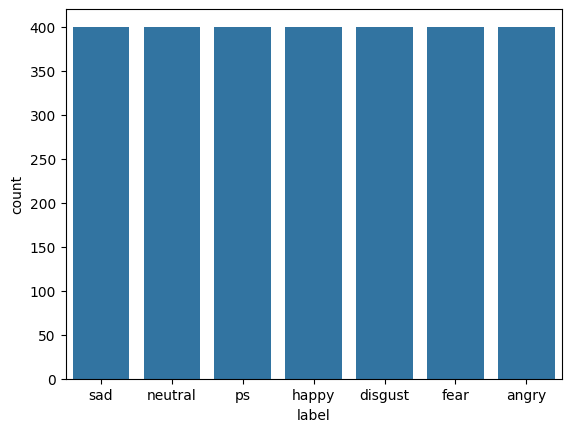

In [ ]:
sns.countplot(df, x='label')

In [ ]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

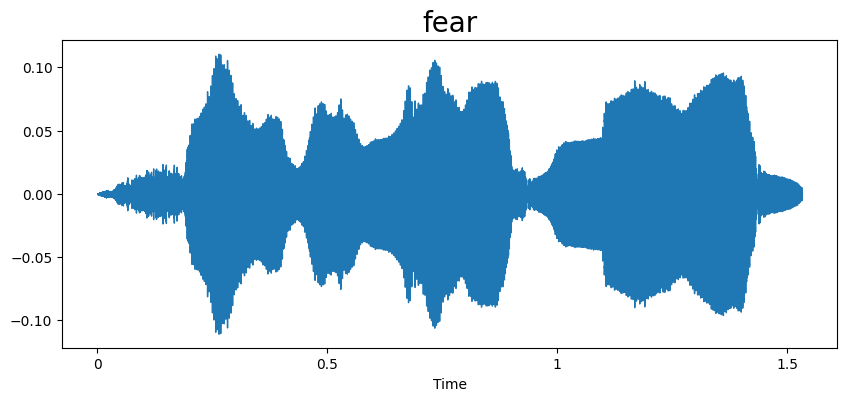

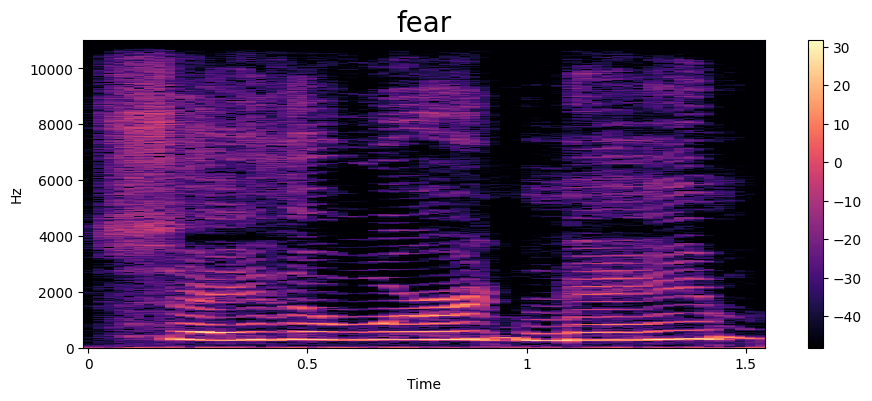

In [ ]:
emotion = 'fear'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)


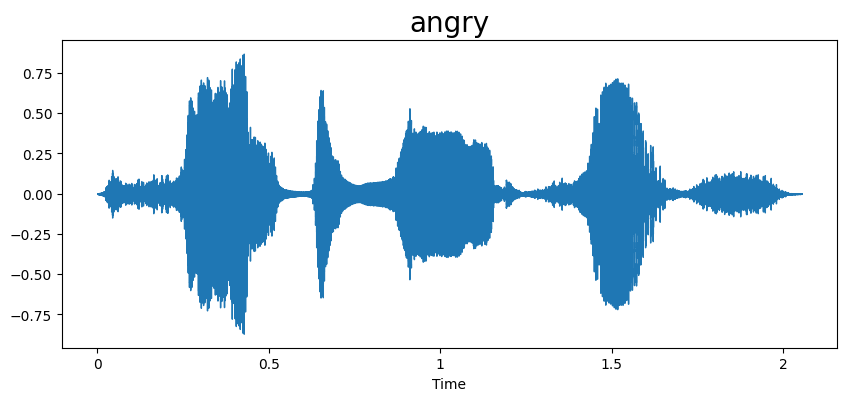

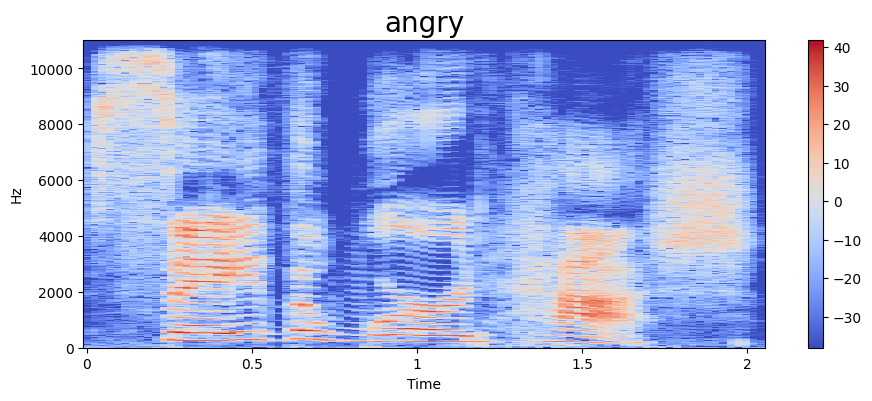

In [ ]:
emotion = 'angry'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

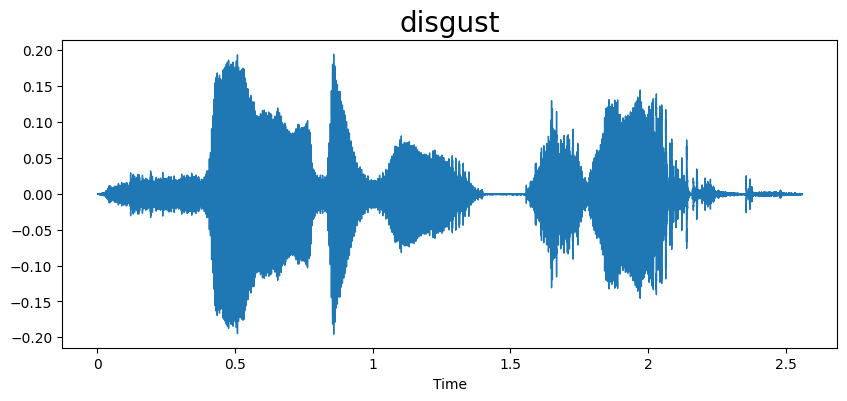

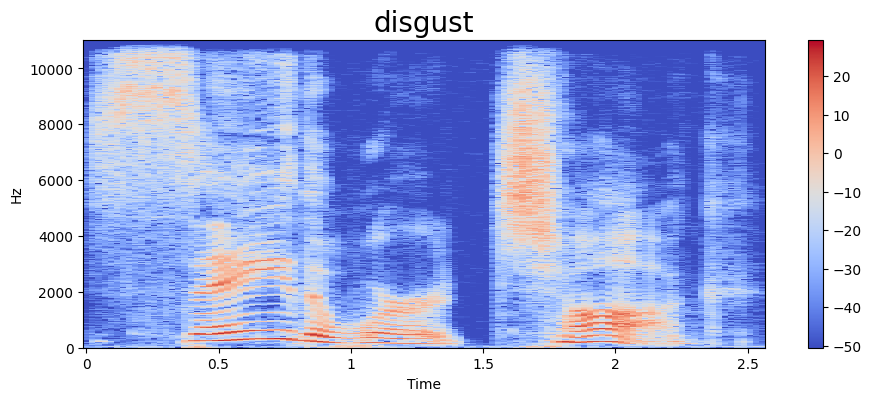

In [ ]:
emotion = 'disgust'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

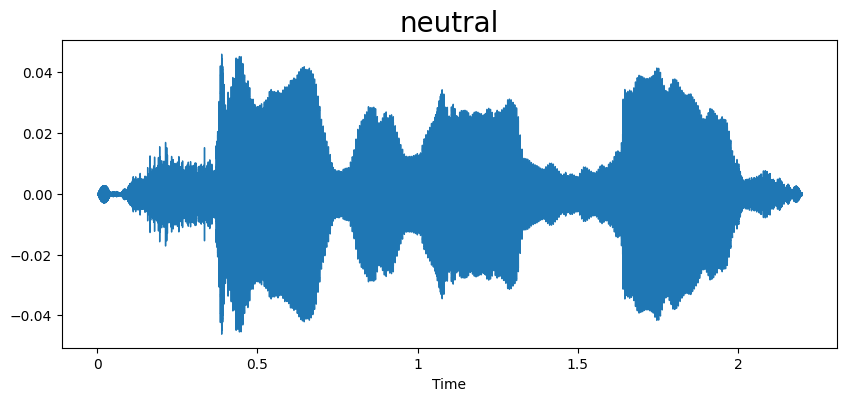

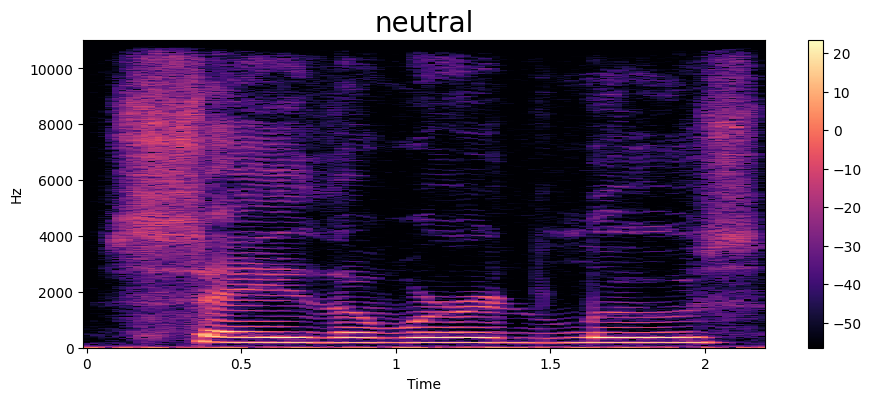

In [ ]:
emotion = 'neutral'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

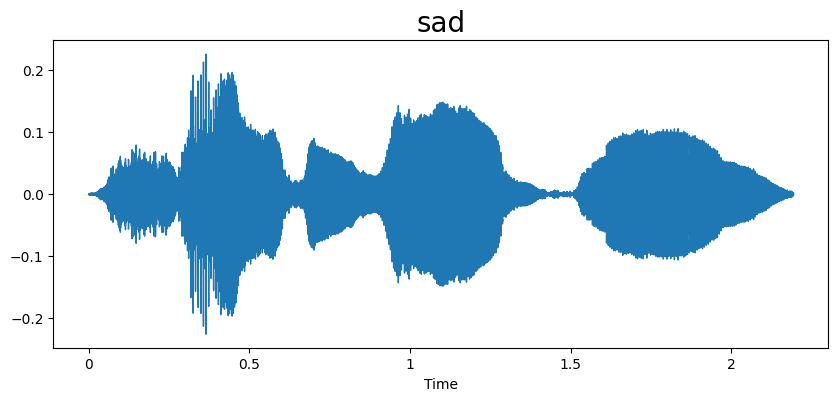

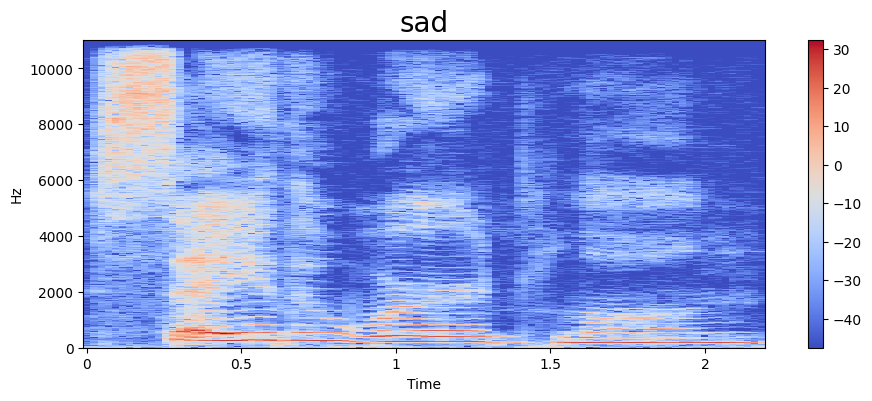

In [ ]:
emotion = 'sad'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

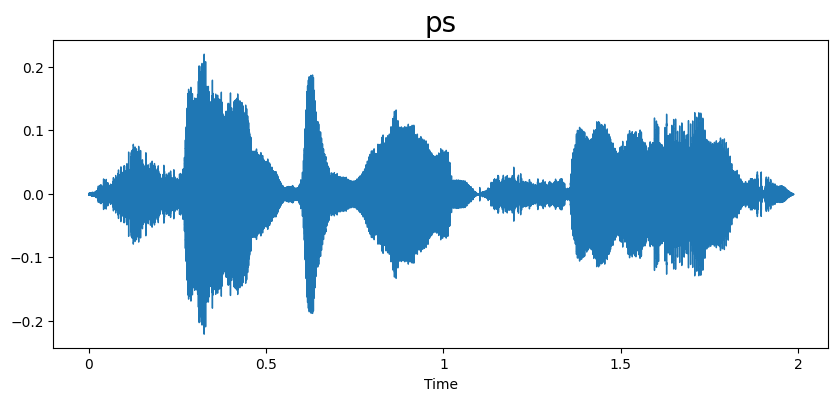

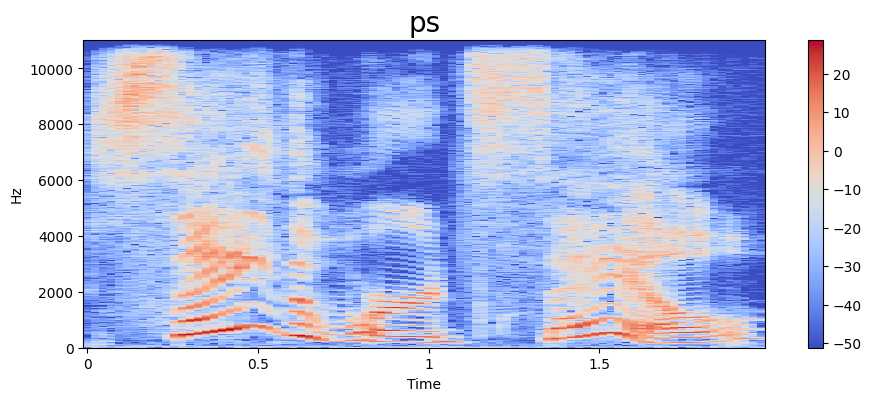

In [ ]:
emotion = 'ps'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

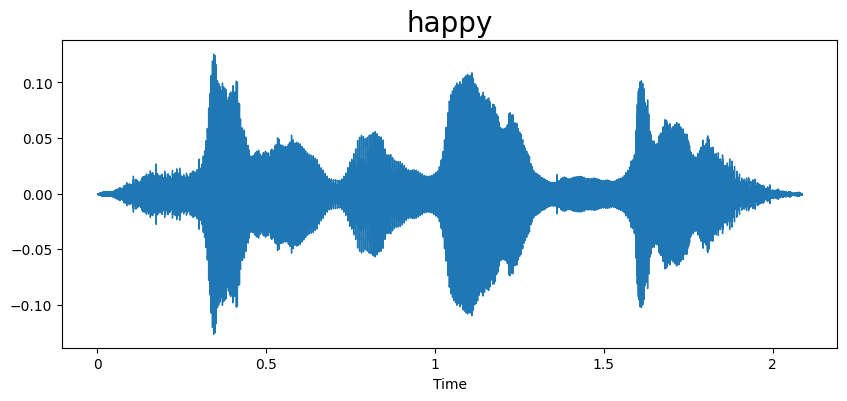

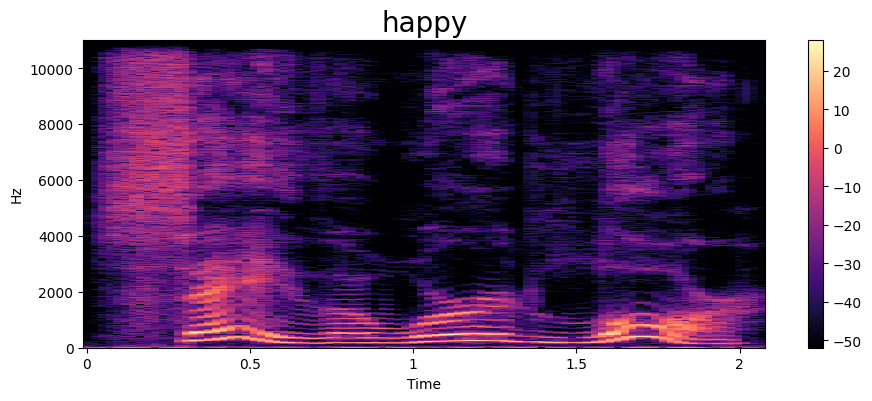

In [ ]:
emotion = 'happy'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
    return mfcc

In [ ]:
extract_mfcc(df['speech'][0])

array([-427.19934   ,  101.87733   ,   30.720917  ,   24.259338  ,
         -5.2000813 ,   13.838268  ,    0.5080207 ,  -18.944881  ,
         -3.1127005 ,  -11.092091  ,   -8.135328  ,   -4.101678  ,
         -5.831726  ,    4.131894  ,  -16.319407  ,    2.8727772 ,
         -8.0660095 ,   -1.7254071 ,   -5.826993  ,   -8.750782  ,
         -7.669864  ,   -7.533113  ,   -8.329036  ,    0.5271387 ,
         -5.210468  ,    7.2041073 ,   -1.6971142 ,    0.45440924,
         -4.2925806 ,   -4.457472  ,   -1.5146097 ,   10.948021  ,
          9.049685  ,   12.684062  ,    7.492414  ,    4.9355216 ,
          6.852972  ,    8.4206705 ,   10.713891  ,   15.528887  ],
      dtype=float32)

In [ ]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))

In [ ]:
X_mfcc

,speech
0,"[-427.19934, 101.87733, 30.720917, 24.259338, ..."
1,"[-409.97375, 99.349174, 28.270508, 43.880848, ..."
2,"[-372.70325, 95.618004, 11.487118, 29.515745, ..."
3,"[-409.69577, 77.89546, 40.513172, 23.02736, -3..."
4,"[-374.0618, 90.32942, 14.085594, 20.008703, -9..."
...,...
2795,"[-470.54465, 88.24481, 26.05667, 0.7661055, 12..."
2796,"[-464.7414, 97.62901, 4.713195, -5.9270973, 17..."
2797,"[-473.4388, 127.29154, 20.212687, -17.877106, ..."
2798,"[-420.2445, 91.05216, 18.892618, -22.403215, -..."


In [ ]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(2800, 40)

In [ ]:
## input split
X = np.expand_dims(X, -1)
X.shape

(2800, 40, 1)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])

In [ ]:
y = y.toarray()

In [ ]:
y.shape

(2800, 7)

In [ ]:
### LSTM Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np

# Define the LSTM model
class LSTMModel(nn.Module):
  def __init__(self, input_size=1, hidden_size=256, num_layers=1, num_classes=7):
    super(LSTMModel, self).__init__()
    self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True
    )
    self.dropout1 = nn.Dropout(0.2)
    self.fc1 = nn.Linear(hidden_size, 128)
    self.dropout2 = nn.Dropout(0.2)
    self.fc2 = nn.Linear(128, 64)
    self.dropout3 = nn.Dropout(0.2)
    self.fc3 = nn.Linear(64, num_classes)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    # LSTM layer
    lstm_out, _ = self.lstm(x)
    # Only take the output from the final time step
    lstm_out = lstm_out[:, -1, :]

    # Fully connected layers with dropout
    x = self.dropout1(lstm_out)
    x = self.relu(self.fc1(x))
    x = self.dropout2(x)
    x = self.relu(self.fc2(x))
    x = self.dropout3(x)
    x = self.fc3(x)
    return self.softmax(x)

# Convert numpy arrays to PyTorch tensors
X_tensor = torch.FloatTensor(X)  # Shape: (batch_size, seq_length=40, input_size=1)
y_tensor = torch.LongTensor(np.argmax(y, axis=1))  # Convert one-hot to class indices

# Create dataset and split for validation
dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Initialize model
model = LSTMModel(input_size=1, hidden_size=256, num_classes=7)
print(model)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

import matplotlib.pyplot as plt

# Initialize lists to store metrics
train_losses = []
train_accs = []
val_losses = []
val_accs = []

num_epochs = 15

# Modified training loop to store metrics
for epoch in range(num_epochs):
  # Training
  model.train()
  train_loss = 0.0
  train_correct = 0
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    _, predicted = torch.max(outputs.data, 1)
    train_correct += (predicted == labels).sum().item()

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    with torch.no_grad():
      for inputs, labels in val_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        val_correct += (predicted == labels).sum().item()

    # Calculate metrics
  train_epoch_loss = train_loss/len(train_loader)
  train_epoch_acc = train_correct/train_size
  val_epoch_loss = val_loss/len(val_loader)
  val_epoch_acc = val_correct/val_size

    # Store metrics
  train_losses.append(train_epoch_loss)
  train_accs.append(train_epoch_acc)
  val_losses.append(val_epoch_loss)
  val_accs.append(val_epoch_acc)

  print(f'Epoch {epoch+1}/{num_epochs}:')
  print(f'Train Loss: {train_epoch_loss:.4f}, Acc: {train_epoch_acc:.4f}')
  print(f'Val Loss: {val_epoch_loss:.4f}, Acc: {val_epoch_acc:.4f}\n')

LSTMModel(
  (lstm): LSTM(1, 256, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=7, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)
Epoch 1/5:
Train Loss: 1.7515, Acc: 0.4134
Val Loss: 1.5785, Acc: 0.6018

Epoch 2/5:
Train Loss: 1.5402, Acc: 0.6299
Val Loss: 1.4801, Acc: 0.6857

Epoch 3/5:
Train Loss: 1.4545, Acc: 0.7143
Val Loss: 1.4078, Acc: 0.7571

Epoch 4/5:
Train Loss: 1.4348, Acc: 0.7339
Val Loss: 1.3913, Acc: 0.7714

Epoch 5/5:
Train Loss: 1.4028, Acc: 0.7634
Val Loss: 1.4016, Acc: 0.7661



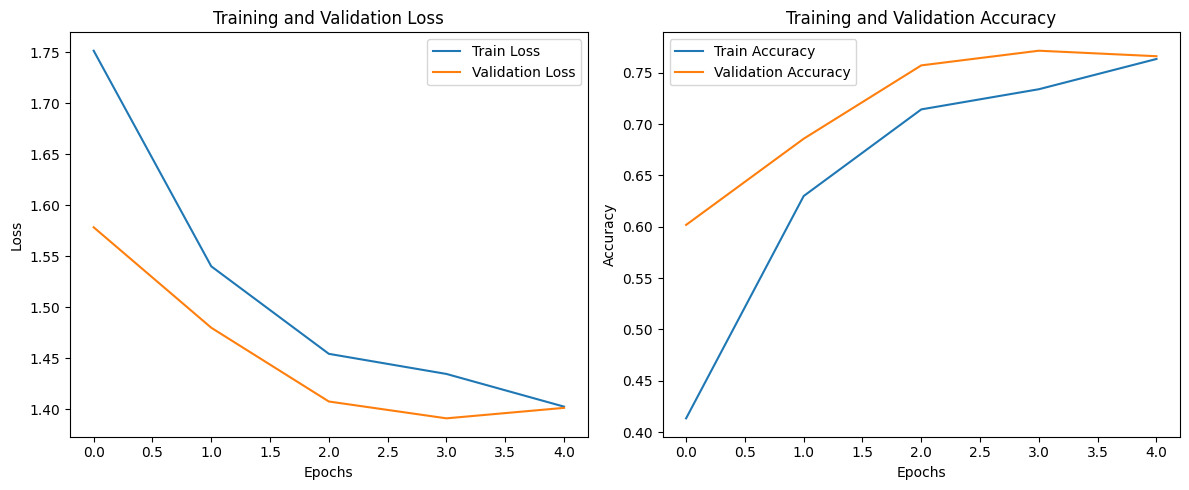

In [ ]:
# Plotting
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

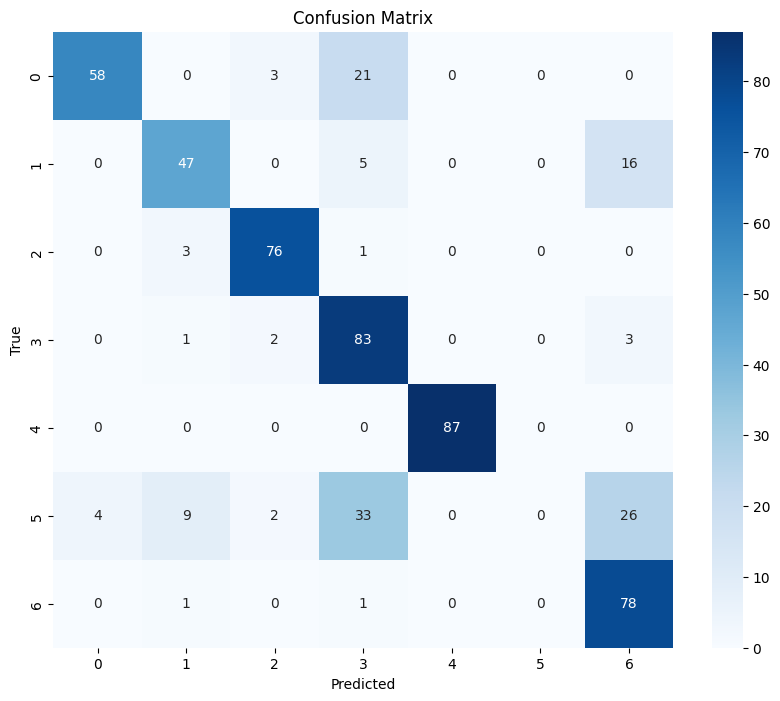

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get all predictions
all_preds = []
all_labels = []
with torch.no_grad():
  for inputs, labels in val_loader:
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    all_preds.extend(preds.numpy())
    all_labels.extend(labels.numpy())

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81        82
           1       0.77      0.69      0.73        68
           2       0.92      0.95      0.93        80
           3       0.58      0.93      0.71        89
           4       1.00      1.00      1.00        87
           5       0.00      0.00      0.00        74
           6       0.63      0.97      0.77        80

    accuracy                           0.77       560
   macro avg       0.69      0.75      0.71       560
weighted avg       0.70      0.77      0.72       560



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
